In [31]:
import logging
import os
import webbrowser
import gpxpy
import geopandas as gpd
import folium
import branca.colormap as cm
from shapely.geometry import Point, LineString
from collections import defaultdict
import pyrosm
from tqdm import tqdm
import matplotlib

In [2]:
PBF_PATH = "moscow.osm.pbf"          # путь к вашему PBF-файлу
GPX_FOLDER = "./tracks/"                    # папка с GPX-треками
OUTPUT_HTML = "moscow_map.html"

In [3]:
osm = pyrosm.OSM(PBF_PATH)

In [ ]:
custom={
        "highway": [
            "footway", "path", "pedestrian", "cycleway",
            "residential", "living_street", "service", "track"
        ]
    }

In [4]:
gdf_edges = osm.get_network(
    network_type="all"
    # custom_filter=custom
)

In [5]:
gdf_edges['highway'].value_counts()

highway
footway           236867
service           169715
path               25352
steps              18770
residential        18147
tertiary           15140
secondary          14623
unclassified        8110
primary             5948
track               4447
cycleway            2046
secondary_link      2021
trunk               1829
construction        1485
tertiary_link       1194
primary_link        1065
proposed             983
living_street        639
pedestrian           578
trunk_link           314
corridor             245
motorway             224
raceway              112
platform              50
bridleway             37
elevator              10
road                   4
rest_area              4
services               2
street_lamp            2
abandoned              2
via_ferrata            1
bus_stop               1
Name: count, dtype: int64

In [14]:
cols = gdf_edges.columns
cols

Index(['access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'busway',
       'cycleway', 'est_width', 'foot', 'footway', 'highway', 'int_ref',
       'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motorroad',
       'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking',
       'path', 'passing_places', 'psv', 'ref', 'service', 'segregated',
       'sidewalk', 'smoothness', 'surface', 'tracktype', 'tunnel', 'turn',
       'width', 'id', 'timestamp', 'version', 'tags', 'osm_type', 'geometry',
       'length'],
      dtype='object')

In [28]:
gdf_edges[cols[0]].value_counts().index

Index(['private', 'customers', 'no', 'permissive', 'destination', 'yes',
       'permit', 'delivery', 'psv', 'no|no', 'official', 'military',
       'designated', 'service', 'restricted', 'forestry', 'agricultural',
       'unknown', 'foot', 'emergency', 'yes|no'],
      dtype='object', name='access')

In [29]:
# исключаем
custom = {
    'access': ['private', 'no', 'permit', 'no|no', 'military', 'restricted'],
    'area': ['no'],
    
}

In [24]:
gdf_edges_custom = osm.get_network(
    custom_filter=custom
)

In [25]:
gdf_edges_custom.columns

Index(['access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'busway',
       'cycleway', 'est_width', 'foot', 'footway', 'highway', 'int_ref',
       'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motorroad',
       'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking',
       'path', 'passing_places', 'psv', 'ref', 'service', 'segregated',
       'sidewalk', 'smoothness', 'surface', 'tracktype', 'tunnel', 'turn',
       'width', 'id', 'timestamp', 'version', 'tags', 'osm_type', 'geometry',
       'length'],
      dtype='object')

In [27]:
gdf_edges_custom['access'].value_counts()

access
private     20402
no           1539
permit        337
no|no          14
military       11
Name: count, dtype: int64

In [32]:
osm_keys_to_keep = "highway"
custom_filter = dict(
        # Areas are not parsed for networks by default
        area=['yes'],
        # OSM "highway" elements that have these tags, cannot be cycled
        highway=['steps', 'corridor', 'elevator', 'escalator', 'motor', 'proposed',
                 'construction', 'abandoned', 'platform', 'raceway', 'motorway', 'motorway_link'],
        # Do not include private roads
        service=['private']
    )

# In this case we want to EXCLUDE all the rows that have tags matching the criteria above
filter_type = "exclude"

# Run and get all cycling roads
gdf_edges_custom = osm.get_data_by_custom_criteria(custom_filter=custom_filter, 
                                          osm_keys_to_keep=osm_keys_to_keep,
                                          filter_type=filter_type)

<Axes: >

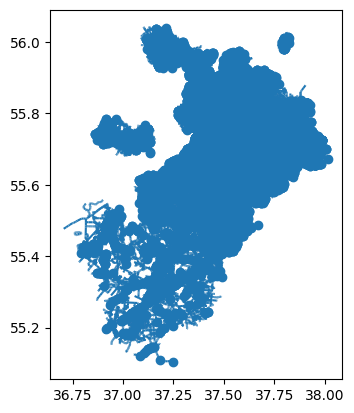

In [33]:
gdf_edges_custom.plot()